In [1]:
# For tips on running notebooks in Google Colab, see
# https://pytorch.org/tutorials/beginner/colab
# El html de este notebook se ha ejecutado usando nbconvert de jupyter, y una plantilla toc2 
# al convertir a HTML. Necesitamos las extensiones de jupyter instaladas, con 
# pip install --upgrade notebook==6.4.12
# pip install jupyter_contrib_nbextensions
# jupyter contrib nbextensions install --user
# Para generar el HTML hacemos
# jupyter nbconvert --to html --template toc2 EntrenandoUnaRedBasica.ipynb
%matplotlib inline

# Guión de prácticas: Desarrollo de un MLP en Pytorch

**Asignatura**: Deep Learning para procesamiento de Lenguaje Natural, 2026/2027

**Profesor**: Juan A. Botía (juanbot@um.es)

**Máster de Inteligencia Artificial**

**Facultad de Informática**

![](https://www.um.es/image/layout_set_logo?img_id=175281&t=1726728636242)

**Universidad de Murcia**

![](https://www.um.es/o/um-lr-principal-um-home-theme/images/logo-um.png)



# Introducción

En este segundo notebook de la asignatura vamos a ver **cómo crear, entrenar y almacenar para su posterior uso un modelo del tipo feed-forward con varias capas**. 

Nos basamos en los tutoriales básicos de la documentación oficial de Pytorch.
En este sentido, este guión de prácticas está basado en los tutoriales básicos 

* [datasets](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html), 

* [transformaciones](https://pytorch.org/tutorials/beginner/basics/transforms_tutorial.html), 

* [construir la red básica](https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html) y 

* [optimizar sus parámetros](https://pytorch.org/tutorials/beginner/basics/optimization_tutorial.html).

En el resto del documento vamos a ver 

* cómo gestionar datos para usarlos en el entrenamiento de un modelo, 

* cómo crear una red neuronal sencilla, y 

* cómo entrenarla y monitorizar su entrenamiento para comprobar que todo está funcionando como esperábamos.

# Gestionando datasets

Cuando queremos crear una red neuronal, lo hacemos para usarla en tareas predictivas, como 

* para predecir el nivel de pluviosidad, 

* para discernir si una imagen indica una situación de riesgo para la seguridad de los ciudadados, 

* o para determinar si un texto incita a la violencia.

Cuando creamos una red neuronal desde cero, sus parámetros se inicializan aleatoriamente. **Para que llegue a desarrollar un rendimiento aceptable en la tarea para la que usamos, es necesario entrenarla.** Y para eso, necesitamos **ejemplos de entrenamiento**. 

Cuando hablamos de ejemplos de entrenamiento, hablamos de puntos muestrales del problema que queremos modelar. Por ejemplo, 

* en un modelo para identificar situaciones de riesgo en un vídeo de un centro comercial, un ejemplo de nuestro dataset será un video de una cámara de un área del centro comercial. 

* Si queremos detectar si existen documentos incitando a la violencia, un ejemplo de entrenamiento será un texto del canal en donde se producen los textos que queremos analizar. 

Tanto si hablamos de videos como de textos, nos referimos a ellos indistintamente como **(1) ejemplos, (2) muestras o (3) instancias** de nuestro dataset.

La naturaleza de estos ejemplos dependerá de la tarea pero todos tienen los mismos componentes

* una serie de atributos que describen al ejemplo particular (e.g., los píxeles describen a una imagen, los datos personales describen a un individuo, los datos clínicos, entre otros, describen a un paciente, etc) y 

* una etiqueta o valor numérico que indica a qué clase pertenece el ejemplo (e.g., si nuestra tarea es reconocer objetos la etiqueta indica el objeto de la imagen, si queremos clasificar documentos la etiqueta se refiere al tipo de documento y si queremos diagnosticar una enfermedad en un individuo, la etiqueta indica si el individuo está enfermo o no). El valor numérico se refiere a una variable numérica a predecir.

A los primeros se les denomina **características** y, alternativamente, *atributos* o *predictores* (el término más frecuente en inglés es *features*). Nos referimos a los segundos con la **clase** del ejemplo en cuestión (también se usa *label* en inglés).

## Clases básicas en Pytorch para trabajar con datos de entrenamiento


Pytorch proporciona una serie de primitivas para ayudarnos en la gestión de datasets. Idealmente, querríamos un código para tartar los datos descacoplado del código para tratar el modelo. PyTorch proporciona dos clases:

* `torch.utils.data.Dataset`: almacena las muestras y sus etiquetas correspondientes.

* `torch.utils.data.DataLoader`: integra al objeto Dataset en forma de iterable, para facilitar el acceso a las muestras y el recorrido a lo largo del conjunto. Ahora lo veremos con un ejemplo.

Recordemos que un [iterable](https://wiki.python.org/moin/Iterator) es un objeto en Python sobre cuyos elementos podemos iterar usando `next(objeto)` o usando cualquier estructura el bucle como un `for`.

## Datasets de ejemplo en Pytorch

En Pytorch podemos encontrar librerías específicas de dominios de aplicación concretos. Es decir, encontramos facilidades para trabajar con imágenes, audio, texto, etc. En todas ellas, además también podemos encontrar datasets con los que podemos trabajar para aprender a usar Pytorch en ese dominio.

Por ejemplo, FashionMNIST es uno de esos datasets y podemos usarlo para trabajar co imágenes sencillas. Todos cuelgan de `torch.utils.data.Dataset` e implementan funciones específicas para el tipo de datos. Se pueden utilizar para crear prototipos y evaluar el rendimiento de tu modelo. 

Puedes encontrarlos aquí:

* [Conjuntos de Datos de Imágenes](https://pytorch.org/vision/stable/datasets.html)

* [Conjuntos de Datos de Texto](https://pytorch.org/text/stable/datasets.html)

* [Conjuntos de Datos de Audio](https://pytorch.org/audio/stable/datasets.html)
    
Para seguir leyendo sobre esta parte de la API,  [torch.utils.data API](https://pytorch.org/docs/stable/data.html).

## Cargando el conjunto MNIST

El conjunto [MNIST](https://yann.lecun.com/exdb/mnist/) es como el *Hola Mundo* del Machine Learning, i.e., el ejemplo de juguete que se ve prácticamente en todos los tutoriales de inicialización a la disciplina cuando usamos redes neuronales. Sin embargo, según cómo se use, algunos argumentan que como problema es excesivamente simple. En respuesta a eso surge Fashion-MNIST. 

A continuación se muestra un ejemplo de cómo cargar y usar el dataset Fashion-MNIST de TorchVision. [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist) es un conjunto de datos de imágenes de artículos vendidos en la Web de Zalando, como respuesta al básico MNIST. Al igual que MNIST (dígitos del 0 al 10), consiste en 60,000 ejemplos de entrenamiento y 10,000 ejemplos de prueba. Cada ejemplo consta de una imagen en escala de grises, como en MNIST, de 28×28 y una etiqueta asociada de una de las 10 clases.

Estos son los tipos de objetos que vamos a aprender a reconocer en Fashion-MNIST, como véis, el nombre no engaña

![](fashion-mnist-sprite.png)

Cargamos el conjunto de datos FashionMNIST con los siguientes parámetros:

* `root`: es la ruta donde se almacenan los datos de entrenamiento/prueba,

* `train`: especifica si es el conjunto de datos de entrenamiento o prueba,

* `download=True`: descarga los datos desde internet si no están disponibles en la ruta proporcionada,

* `transform`: una función de transformación para aplicar a las imágenes. En este caso, convertimos cada imagen en un tensor.



In [2]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


# Definimos las transformaciones que se aplicarán a las imágenes
transform = transforms.Compose([transforms.ToTensor()])

# Cargamos el conjunto de datos de entrenamiento y prueba
train_dataset = datasets.FashionMNIST(root="data", train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root="data", train=False, download=True, transform=transform)

# Creamos los cargadores de datos
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## Recorriendo el datataset para visualizarlo

Podemos indexar `Datasets` como vemos abajo, en forma de lista, mediante la variable: `train_dataset[index]`. 
Y usamos  `matplotlib` para visualizar algunas imágenes de entrenamiento.

El ejemplo siguiente es muy sencillo. Recorre aleatoriamente el dataset para formar un grid de $3\times 3$ ejemplos en los que va añadiendo as imágenes leidas desde `train_dataset[]` colocándoles su título correspondiente. 

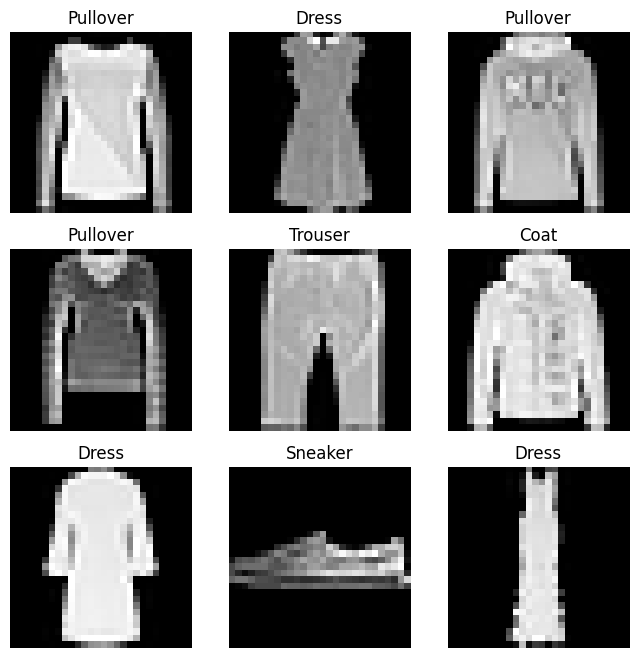

In [3]:
import torch
import matplotlib.pyplot as plt
import numpy 
from torchvision.transforms import ToTensor

labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
    img, label = train_dataset[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()


<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>Pregunta: las figuras se ven demasiado pixeladas porque se visualizan con un tamaño excesivo. Cambia el código para que aparezcan más pequeñas en el notebook.</strong></div>



## Preparar los datos para el entrenamiento con DataLoaders

El Dataset proporciona un ejemplo cada vez (atributos y etiqueta de clase). Mientras entrenamos un modelo, normalmente queremos 

* acceder a las muestras en grupos (i.e., *minilotes* ó *minibatches* en la literatura en inglés), 

* cada vez que todos los datos pasan por la red, barajarlos aleatoriamente para evitar el sobreajuste del modelo (veremos esto qué significa más adelante), 

* y usar el multiprocessing de Python para acelerar la recuperación de datos. 

Todo esto se verá más a fondo en la asignatura de Machine Learning de este mismo máster.

Pero nos lo va a dar la clase DataLoader, que es un iterable que abstrae esta complejidad para nosotros en una API fácil de usar. En este caso vamos a 

* definir un cargador de datos que lee el dataset en lotes de **64 ejemplos** y, 

* cada vez que hace una pasada por el conjunto de datos, **baraja** (*shuffle*) el dataset para que cada vez que se pase por él, no se coincida en orden con la vez anterior. 

Para más información sobre cómo acceder de manera más precisa a los `DataLoaders` ver [Samplers](https://pytorch.org/docs/stable/data.html#data-loading-order-and-sampler)).

Responde tú mismo a la pregunta ¿qué está haciendo el código que vemos a continuación?


Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


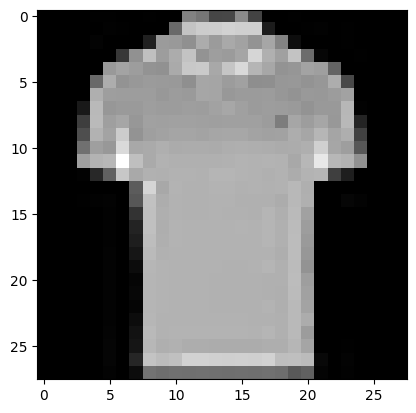

Label: 0


In [4]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=True)

# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

# Normalizar datos de entrada y codificar valores de clase a one-hot

Los datos no siempre nos llegan en la forma en que los requiere la combinación de modelo y algoritmo de machine learning que usamos. En este caso, un MLP (perceptrón multi-capa) cuyos pesos optimizaremos mediante SGD (Stochastic Gradient Descent).

**Si necesitamos manipular los datos para transformarlos, echamos mano de transformaciones**. Algunas transformaciones típicas incluyen cualquier cambio que podamos aplicar a una imagen: recorte, proyección, filtrado, etc. Pero una simple normalización también es una transformación.

Cuando definimos transformaciones, podemos actuar sobre las características o sobre la etiqueta de clase, si estamos en un problema supervisado. En consecuencia, todos los conjuntos de datos de TorchVision tienen dos parámetros: 

* `transform` para modificar las características y 

* `target_transform` para modificar las etiquetas. 

Estas variables contienen las correspondientes funciones que transformarían las correspondientes partes del dataset. 

Las características de FashionMNIST están en formato de imagen PIL, y las etiquetas son enteros. 
Para usar las imágenes en el entrenamiento del MLP mediante SGD, necesitamos

* las características como tensores normalizados, 

* las etiquetas como tensores codificados en one-hot. 

Para realizar estas transformaciones, usamos ToTensor y Lambda. Para leer más sobre el tema, ver [torchvision.transforms](https://pytorch.org/vision/stable/transforms.html).

Explica tú mismo qué ocurre en este código.

In [5]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))
)
loader = DataLoader(ds, batch_size=3, shuffle=True)
example_features, example_label = next(iter(loader))
print(example_label)
print(f"La imagen 1 corresponde a una {labels_map[torch.nonzero(example_label[0]).item()]}")
print(f"La siguiente imagen corresponde a una {labels_map[torch.nonzero(example_label[1]).item()]}")
print(f"La imagen 3 corresponde a una {labels_map[torch.nonzero(example_label[2]).item()]}")


tensor([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]])
La imagen 1 corresponde a una Sneaker
La siguiente imagen corresponde a una Ankle Boot
La imagen 3 corresponde a una Shirt


# La red neuronal


Ahora vamos a crear la red neuronal. Las redes neuronales en Pytorch son totalmente modulares. Están diseñadas por capas/módulos que realizan operaciones sobre los datos en un orden claramente especificado.

El espacio de nombres `torch.nn` proporciona todos los bloques de construcción que necesitas para crear tu propia red neuronal (ver documentación [aquí](https://pytorch.org/docs/stable/nn.html)).

Como sabes, Python es orientado a objetos (OO) y Pytorch usa el OO al organizar su código. Por eso, **toda red neuronal de Pytorch es subclase de `nn.Module`**. Una red neuronal es un conjunto de módulos de red neuronal: capas de red con funciones diversas (e.g., lineales, de recurrencia, transformers, de convolución, de padding, etc.), funciones de activación, todos estos elementos son módulos que pueden ser componentes de una red. 

La idea es que una red neuronal se conforme como una estructura arbórea de módulos, accesibles mediante atributos de la clase. Esta estructura anidada permite construir y gestionar arquitecturas complejas con facilidad. El método que inicia el objeto, `__init__()` siempre ha de llamar al de la superclase para que la inicialización del objeto sea correcta.

## Definiendo una red de dos capas ocultad de encadenamiento hacia delante

En el siguiente ejemplo vemos que definimos la clase `NeuralNetwork` que hereda de `nn.Module`, al indicar `class NeuralNetwork(nn.Module)`. 

La composición interna del tipo de red neuronal que vamos a desarrollar necesita especifiarse nada más crearse la clase. 
Por tanto, el lugar en donde indicarlo es el método `__init__()`. En el ejemplo de abajo, 

* tras llamar al mismo método de la superclases, 

* definimos dos variables de clase, `flatten` en donde almacenamos la función que usaremos para aplanar el tensor de la entrada para poder introducirlo a la primera capa de 28*28 nodos

* `linear_relu_stack` en donde almacenamos la propia red: tres capas lineales, una sobre otra, separadas por dos capas alternas de funciones de activación ReLU. La primera capa acepta como entrada 784 valores y genera 512 nodos a la salida. La segunda acepta esos 512 nodos y genera otros 512. La tercera los acepta y genera a la salida 10 nodos. 

Como vemos, la red es secuencial (o lo que en teoría hemos visto como de encadenamiento hacia delante o feed-forward): el ejemplo de entrenamiento entra por un extremo, se va procesando en pasos sucesivos, sin ciclos, y lo que se genera en el otro extremo es la salida de la red. 

El método forward usa la capa de tipo `nn.Sequential` que hemos definido en la variable `linear_relu_stack` para hacer inferencia, pero previamente aplanamos el tensor de $28\times 28$, llamando a la función `nn.Flatten()`.


In [6]:
from torch import nn
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits


Ya tenemos el modelo. Podríamos indagar un poquito más sobre él.
Podríamos preguntarnos internamente, cómo sabemos realmente cuál es el tamaño de las matrices de pesos que se han creado realmente. Para eso, necesitamos acceder a los parámetros del modelo y, esencialmente a `linear_relu_stack`. 

Si miramos en la documentación, hay un método [named_parameters()](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.named_parameters) que nos permite acceder a la lista de parámetros del modelo y sus nombres. Naturalmente, los parámetros son tensores.

Podemos acceder a cada parámetro iterando sobre ellos y a sus datos mediante el nombre, y la variable de clase `.data`.


In [7]:
#Creamos el modelo
model = NeuralNetwork()
for name, param in model.named_parameters():
    print(f"Nombre del parámetro {name} y tamaño {model.get_parameter(name).data.shape}")
    

Nombre del parámetro linear_relu_stack.0.weight y tamaño torch.Size([512, 784])
Nombre del parámetro linear_relu_stack.0.bias y tamaño torch.Size([512])
Nombre del parámetro linear_relu_stack.2.weight y tamaño torch.Size([512, 512])
Nombre del parámetro linear_relu_stack.2.bias y tamaño torch.Size([512])
Nombre del parámetro linear_relu_stack.4.weight y tamaño torch.Size([10, 512])
Nombre del parámetro linear_relu_stack.4.bias y tamaño torch.Size([10])


Como vemos, tenemos parámetros para las tres capas y los correspondientes sesgos.


# Optimización de parámetros de la red

Ahora que tenemos un modelo y datos, es momento de **entrenar, validar y probar** nuestro modelo optimizando sus parámetros con nuestros datos. 

Entrenar un modelo es un proceso iterativo. En cada iteración, el modelo 

* hace una predicción sobre la salida, 

* calcula el error en su predicción (pérdida), 

* recolecta las derivadas del error con respecto a sus parámetros (como vimos en el primer notebook de diferenciación automática), 

* y optimiza estos parámetros utilizando el descenso de gradiente. 

Partimos del código básico siguiente que es, básicamente, una recopilación de todo lo que hemos ido desarrollando por trozos en los ejemplos de arriba.

Queremos poder entrenar nuestro modelo en un acelerador de hardware como la GPU o MPS, si está disponible. 

Vamos a verificar si [torch.cuda](https://pytorch.org/docs/stable/notes/cuda.html) ó
[torch.backends.mps](https://pytorch.org/docs/stable/notes/mps.html) están disponibles; de lo contrario, utilizamos la CPU. 




In [8]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using mps device


Ahora, ya hemos inicializado nuestro dispositivo de computación. Yo estoy desarrollando con un Mac y mi device particular es `mps`, correspondiente al Metal Programming Framework. Pero el tuyo puede ser cualquier otro de los posibles. Creamos una instancia de NeuralNetwork, la movemos al device y mostramos su estructura. 

In [9]:
model = NeuralNetwork().to(device)
print(model)


NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)



Para usar el modelo, ya sabemos que debemos pasarle los datos de entrada y él se encarga de hacer una pasada hacia delante. Es decir, ejecuta el `forward()` del modelo, junto con algunas operaciones en segundo plano. Nunca deberíamos llamar a `model.forward()` si no sabemos bien lo que estamos haciendo.


Como vemos, simplemente usando el nombre de la variable `model`, a modo de función, cuando hacemos `model(X)`, conseguimos llamar a `forward()`. Esto se consigue mediante el mecanismo de sobrecarga de operadores del Python OO. Si echamos un vistazo al código fuente de `nn.Module` veremos que la función `__call__` está definida en la clase `nn.Module` y que lo que hace es precisamente llamar a `forward()`.  


In [10]:
X = torch.rand(1, 28, 28, device=device)
logits = model(X)
pred_probab = nn.Softmax(dim=1)(logits)
y_pred = pred_probab.argmax(1)
print(f"Predicted class: {y_pred}")

Predicted class: tensor([9], device='mps:0')



Vamos a ver ahora cómo trabaja cada una de las capas de nuestro modelo.  Para ilustrarlo, tomamos un minibatch de ejemplo de 3 imágenes de tamaño 28x28 y vemos qué sucede cuando lo pasamos a través de módulos idénticos a los que maneja la red internamente. 



In [11]:
input_image = torch.rand(3,28,28)
print(input_image.size())

torch.Size([3, 28, 28])




Recordemos que `nn` hemos importando el módulo `torch.nn`. Inicializamos entonces la función nn.Flatten para convertir cada imagen 2D de 28x28 en un array continuo de 784 valores de píxeles (se mantiene la dimensión del minibatch en dim=0). Esta función toma como entrada cualquier tensor. Esto quiere decir que puede tomar como entrada otra capa anterior, de la cual tomaría sus correspondientes pesos y sesgos, que transformaría en un vector de una dimensión.



In [12]:
flatten = nn.Flatten()
flat_image = flatten(input_image)
print(flat_image.size())

torch.Size([3, 784])


Después de esto, aplicamos una capa lineal que hace lo mismo que la que recreamos aquí, que toma como entrada la imagen que acabamos de aplanar.

In [13]:
layer1 = nn.Linear(in_features=28*28, out_features=20)
hidden1 = layer1(flat_image)
print(hidden1.size())

torch.Size([3, 20])




Como hemos visto, después de la capa lineal fully connected, aplicamos una función de activación ReLU en este caso. Es una función de activación no  lineal. Las activaciones no lineales son las que crean las asociaciones complejas entre las entradas y salidas del modelo. 
Se aplican después de las transformaciones lineales para introducir no linealidad, ayudando a las redes neuronales a aprender una gran variedad de fenómenos.

En este modelo, utilizamos `nn.ReLU` entre nuestras capas lineales, pero hay otras activaciones para introducir no linealidad en tu modelo. 



In [14]:
print(f"Antes de la ReLU: {hidden1}\n\n")
hidden1 = nn.ReLU()(hidden1)
print(f"Después de la ReLU: {hidden1}")

Antes de la ReLU: tensor([[-0.0455, -0.1210,  0.0466, -0.2855,  0.2014, -0.2242,  0.1370, -0.6003,
         -0.0143, -0.0142,  0.0232, -0.0826, -0.3261, -0.5104, -0.3621, -0.7045,
         -0.3826,  0.0989,  0.1839, -0.7390],
        [-0.3495,  0.0199,  0.5318,  0.0230,  0.3704, -0.4554,  0.1161, -0.4648,
          0.1353,  0.2740, -0.1067, -0.1024,  0.0379, -0.5390, -0.3281, -0.3601,
         -0.0683, -0.0763,  0.2992, -0.8774],
        [-0.1783,  0.2016,  0.1382,  0.1527,  0.2532, -0.1301,  0.4763, -0.4390,
          0.1580,  0.2500, -0.2695, -0.3229,  0.1046, -0.5439,  0.0060, -0.2127,
          0.0011,  0.4231,  0.3330, -0.6935]], grad_fn=<AddmmBackward0>)


Después de la ReLU: tensor([[0.0000, 0.0000, 0.0466, 0.0000, 0.2014, 0.0000, 0.1370, 0.0000, 0.0000,
         0.0000, 0.0232, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0989,
         0.1839, 0.0000],
        [0.0000, 0.0199, 0.5318, 0.0230, 0.3704, 0.0000, 0.1161, 0.0000, 0.1353,
         0.2740, 0.0000, 0.0000, 0.0379,





nn.Sequential es un contenedor ordenado de módulos. Los datos se pasan a través de todos los módulos en el mismo orden en que fueron definidos. Puedes usar contenedores secuenciales para construir rápidamente una red, como seq_modules. 



In [15]:
seq_modules = nn.Sequential(
    flatten,
    layer1,
    nn.ReLU(),
    nn.Linear(20, 10)
)
input_image = torch.rand(3,28,28)
logits = seq_modules(input_image)



La última capa lineal de la red neuronal devuelve los logits, valores crudos en $[-\infty,\infty]$, que se pasan al módulo `nn.Softmax`. 
Los logits se escalan a valores entre [0,1], que representan las probabilidades predichas por el modelo para cada clase. El parámetro `dim` indica la dimensión a lo largo de la cual los valores deben sumar 1.



In [16]:
softmax = nn.Softmax(dim=1)
pred_probab = softmax(logits)



Muchas capas dentro de una red neuronal están parametrizadas, es decir, tienen pesos y sesgos asociados que se optimizan durante el entrenamiento. Subclasificar nn.Module rastrea automáticamente todos los campos definidos dentro de tu objeto de modelo y hace que todos los parámetros sean accesibles usando los métodos parameters() o named_parameters() de tu modelo.

En este ejemplo, iteramos sobre cada parámetro y mostramos su tamaño y una vista previa de sus valores.

In [17]:
print(f"Model structure: {model}\n\n")

for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")

Model structure: NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


Layer: linear_relu_stack.0.weight | Size: torch.Size([512, 784]) | Values : tensor([[ 0.0125, -0.0064, -0.0107,  ...,  0.0336, -0.0242,  0.0053],
        [-0.0328,  0.0022,  0.0105,  ...,  0.0037, -0.0300,  0.0224]],
       device='mps:0', grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.0.bias | Size: torch.Size([512]) | Values : tensor([-0.0298, -0.0314], device='mps:0', grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.2.weight | Size: torch.Size([512, 512]) | Values : tensor([[-0.0342,  0.0183, -0.0163,  ...,  0.0229, -0.0347,  0.0288],
        [-0.0038, -0.0224,  0.0211,  ...,  0.0200,  0.0269, -0.0303]],
       device='mps:0', grad_fn=<Slice

In [18]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

train_dataloader = DataLoader(training_data, batch_size=64)
test_dataloader = DataLoader(test_data, batch_size=64)

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork()

# Hiperparámetros de nuestra red


Ya hemos visto en las clases de teoría que los hiperparámetros son parámetros ajustables que te permiten controlar el proceso de optimización del modelo. Diferentes valores de hiperparámetros pueden impactar en la calidad del entrenamiento del modelo y la velocidad de convergencia. Un tutorial específico sobre el tema en Pytorch es este de [aquí](https://pytorch.org/tutorials/beginner/hyperparameter_tuning_tutorial.html).

Definimos los siguientes hiperparámetros para el entrenamiento:

* epochs: el número de veces que se itera sobre el conjunto de datos.

* batch size: la cantidad de muestras de datos que se propagan a través de la red antes de que se actualicen los parámetros.

* learning rate: cuánto se actualizan los parámetros del modelo en cada lote/época. Los valores más pequeños producen una velocidad de aprendizaje más lenta, mientras que los valores grandes pueden resultar en un comportamiento impredecible durante el entrenamiento.


In [19]:
learning_rate = 1e-3
batch_size = 64
epochs = 5

## Bucle de Optimización

Una vez que establecemos nuestros hiperparámetros, podemos entrenar y optimizar nuestro modelo con un bucle de optimización. Cada iteración del bucle de optimización se llama época. Una época se completa cada vez que **todos** los ejemplos de entrenamiento han pasado por la red neuronal y han intervenido en el entrenamiento.
Cada una de esas épocas consta de dos partes principales:

* **El Bucle de Entrenamiento:** en este bucle, iteramos sobre los ejemplos del conjunto de entrenamiento para minimizar la función de pérdida y converger hacia los parámetros óptimos mediante la técnica de optimización que le hayamos indicado (seguramente SGD o similar).

* **El Bucle de Validación/Prueba:** en este bucle, que suele ejecutarse solo cuando el de entrenamiento se ha ejecutado una o más veces, se itera sobre el conjunto de datos de prueba (distinto al de entrenamiento) para verificar si el rendimiento del modelo está mejorando. Téngase en cuenta que estos ejemplos no son vistos en el entrenamiento por lo que lo que se está haciendo en realidad es intentar estimar la capacidad de predicción del modelo en ejemplos desconocidos.

Su programación completa viene descrita aquí, pero básicamente se basa en varias ideas principales:

* el código está diseñado de tal forma que podemos usar un ejemplo o n (batch) en cada llamada

* la secuencia suele ser siempre la misma, a repetir en cada época:

    - Obtenemos los siguientes ejemplos de entrenamiento en $X$

    - Hacemos inferencia con $X$ llamando a `model(X)`

    - Llamamos a la función de pérdida con la predicción y le serie de etiquetas reales para los ejemplos en $X$

    - Calculamos gradientes con la llamada `loss.backward()`

    - Actualizamos los pesos con `optimizar.step()` (opcionalmente ponemos a cero los gradientes)

* Cada cierto tiempo reportamos la evolución del entrenamiento

In [20]:
def train_loop(dataloader, model, loss_fn, optimizer):
    #Vamos a necesita después el tamaño total del conjunto para ratios de acierto (accuracy)
    size = len(dataloader.dataset)
    for batch, (X, y) in enumerate(dataloader):
        # Genera predicciones para todos los ejemplos del lote
        pred = model(X)
        #Calcula la pérdida para todas las predicciones correspondientes del lote
        loss = loss_fn(pred, y)

        # Calcula los gradientes desde la capa final hacia la de entrada
        loss.backward()
        #Actualiza el modelo una vez calculados los gradientes
        optimizer.step()
        #Resetea los gradientes 
        optimizer.zero_grad()
        #Si hemos actualizado los pesos un número de veces suficiente,
        #entonces reportamos (para no ser demasiado ruidosos)
        if batch % 100 == 0:
            #Vamos a reportar la pérdida acumulada, dado el número de ejemplos
            #que hemos procesado de entre todos los del conjunto total
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

Ahora, usamos una entropía cruzada, y un gradiente descendente estocástico, con el ratio de aprendizaje que hemos definido arriba. 
Y probamos el modelo!

In [21]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.310832  [   64/60000]
loss: 2.297259  [ 6464/60000]
loss: 2.277770  [12864/60000]
loss: 2.265318  [19264/60000]
loss: 2.262839  [25664/60000]
loss: 2.229626  [32064/60000]
loss: 2.243153  [38464/60000]
loss: 2.212091  [44864/60000]
loss: 2.218120  [51264/60000]
loss: 2.180055  [57664/60000]
Test Error: 
 Accuracy: 40.0%, Avg loss: 2.178747 

Epoch 2
-------------------------------
loss: 2.196391  [   64/60000]
loss: 2.184761  [ 6464/60000]
loss: 2.132969  [12864/60000]
loss: 2.135122  [19264/60000]
loss: 2.104532  [25664/60000]
loss: 2.045360  [32064/60000]
loss: 2.074306  [38464/60000]
loss: 2.006048  [44864/60000]
loss: 2.027168  [51264/60000]
loss: 1.937823  [57664/60000]
Test Error: 
 Accuracy: 51.1%, Avg loss: 1.943366 

Epoch 3
-------------------------------
loss: 1.986273  [   64/60000]
loss: 1.953385  [ 6464/60000]
loss: 1.845525  [12864/60000]
loss: 1.864586  [19264/60000]
loss: 1.776558  [25664/60000]
loss: 1.717404  [32064/600